In [1]:
%load_ext autotime

import scarf
import scarf.plotting as splt

scarf.__version__

'1.0.0'

time: 1.4 s (started: 2026-07-16 23:13:56 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name="kang_15K_pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

scarf.fetch_dataset(
    dataset_name="kang_14K_ifnb-pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

time: 24.5 s (started: 2026-07-16 23:13:57 +02:00)


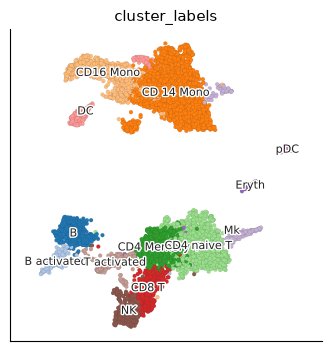

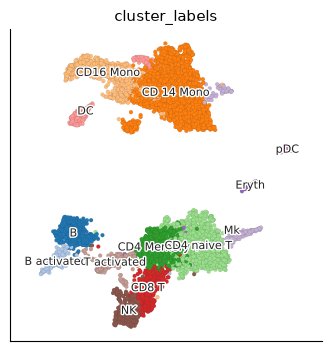

time: 705 ms (started: 2026-07-16 23:14:22 +02:00)


In [3]:
# Control/untreated PBMC data
ds_ctrl = scarf.DataStore("scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr", nthreads=4)

splt.embedding(
    ds_ctrl,
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
    show=False,
).figure

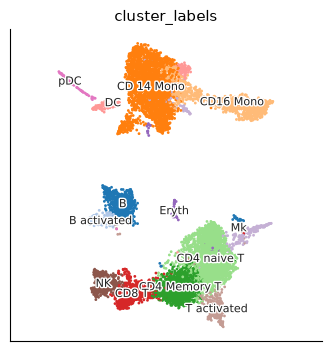

time: 327 ms (started: 2026-07-16 23:14:22 +02:00)


In [4]:
# Interferon beta stimulated PBMC data
ds_stim = scarf.DataStore(
    "scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr", nthreads=4
)

splt.embedding(
    ds_stim,
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
    show=False,
).figure

In [5]:
ds_ctrl.run_mapping(
    target_assay=ds_stim.RNA, target_name="stim", target_feat_key="hvgs_ctrl", save_k=5
)

0 features missing in target data



Loaded existing ANN stream from RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__50__50__48__4466



time: 3.09 s (started: 2026-07-16 23:14:23 +02:00)


In [6]:
# Here we will generate plots for IFB-B stimulated cells from NK  and CD14 monocyte clusters.

for g, ms in ds_ctrl.get_mapping_score(
    target_name="stim",
    target_groups=ds_stim.cells.fetch("cluster_labels"),
    log_transform=True,
):
    if g in ["NK", "CD 14 Mono"]:
        print(f"Target cluster {g}")
        splt.embedding(
            ds_ctrl,
            layout_key="RNA_UMAP",
            color_by="cluster_labels",
            point_sizes=ms * 10,
            figsize=(4, 4),
            show=False,
        ).figure

Target cluster CD 14 Mono


Target cluster NK
time: 679 ms (started: 2026-07-16 23:14:26 +02:00)


In [7]:
transferred_labels = ds_ctrl.get_target_classes(
    target_name="stim", reference_class_group="cluster_labels"
)

transferred_labels

0               CD8 T
1                 pDC
2         CD4 naive T
3                   B
4        CD4 Memory T
             ...     
10106       CD16 Mono
10107              NA
10108               B
10109       CD16 Mono
10110     CD4 naive T
Length: 10111, dtype: object

time: 298 ms (started: 2026-07-16 23:14:26 +02:00)


In [8]:
evidence = ds_ctrl.get_target_label_evidence(
    target_name="stim", reference_class_group="cluster_labels", threshold_fraction=0.6
)
evidence.head()

,label,voteFraction,voteEntropy,topTwoMargin,featureCoverage,referenceDistancePercentile,isUnknown
0,CD8 T,0.804400,0.494241,0.608801,1.0,0.846844,False
1,pDC,1.000000,-0.000000,1.000000,1.0,0.988430,False
2,CD4 naive T,1.000000,-0.000000,1.000000,1.0,0.882524,False
3,B,1.000000,-0.000000,1.000000,1.0,0.959955,False
4,NA,0.567653,0.683965,0.135306,1.0,0.835427,True


time: 438 ms (started: 2026-07-16 23:14:25 +02:00)


In [9]:
ds_stim.cells.insert("transferred_labels", transferred_labels.values, overwrite=True)

time: 32.6 ms (started: 2026-07-16 23:14:26 +02:00)


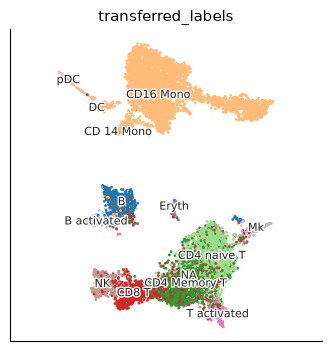

time: 239 ms (started: 2026-07-16 23:14:26 +02:00)


In [10]:
splt.embedding(
    ds_stim,
    layout_key="RNA_UMAP",
    color_by="transferred_labels",
    show=False,
).figure

In [11]:
import pandas as pd

df = pd.crosstab(
    ds_stim.cells.fetch("cluster_labels"), ds_stim.cells.fetch("transferred_labels")
)
df

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,495,5,0,78,13,2,2,0,0,3,146,0,1,1
B activated,24,138,0,11,2,0,0,0,0,0,28,1,1,0
CD 14 Mono,0,0,5,2527,0,0,0,0,0,0,0,0,0,0
CD16 Mono,0,0,0,956,0,0,0,0,0,0,0,0,0,0
CD4 Memory T,0,0,0,8,668,103,118,0,0,1,398,0,1,0
CD4 naive T,3,0,0,17,335,1600,16,0,0,0,412,2,5,0
CD8 T,0,0,0,1,12,2,588,0,0,0,27,24,1,0
DC,0,0,0,204,1,0,0,8,0,0,1,0,0,0
Eryth,0,0,0,15,9,16,2,0,38,0,3,0,0,0


time: 80.1 ms (started: 2026-07-16 23:14:26 +02:00)


In [12]:
(100 * df / df.sum(axis=0)).round(1)

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,94.8,3.5,0.0,2.0,1.2,0.1,0.2,0.0,0.0,2.8,13.0,0.0,0.7,2.8
B activated,4.6,96.5,0.0,0.3,0.2,0.0,0.0,0.0,0.0,0.0,2.5,0.3,0.7,0.0
CD 14 Mono,0.0,0.0,71.4,64.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CD16 Mono,0.0,0.0,0.0,24.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CD4 Memory T,0.0,0.0,0.0,0.2,62.1,5.7,14.3,0.0,0.0,0.9,35.5,0.0,0.7,0.0
CD4 naive T,0.6,0.0,0.0,0.4,31.2,89.2,1.9,0.0,0.0,0.0,36.8,0.5,3.4,0.0
CD8 T,0.0,0.0,0.0,0.0,1.1,0.1,71.1,0.0,0.0,0.0,2.4,6.6,0.7,0.0
DC,0.0,0.0,0.0,5.2,0.1,0.0,0.0,100.0,0.0,0.0,0.1,0.0,0.0,0.0
Eryth,0.0,0.0,0.0,0.4,0.8,0.9,0.2,0.0,97.4,0.0,0.3,0.0,0.0,0.0


time: 9.34 ms (started: 2026-07-16 23:14:26 +02:00)


In [13]:
ds_ctrl.run_unified_umap(
    target_names=["stim"],
    ini_embed_with="RNA_UMAP",
    target_weight=1,
    use_k=5,
    n_epochs=100,
)

Training UMAP:   0%|                                                                                          …

time: 10 s (started: 2026-07-16 23:14:26 +02:00)


/home/parashar/scarf/scarf/metadata.py:416: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


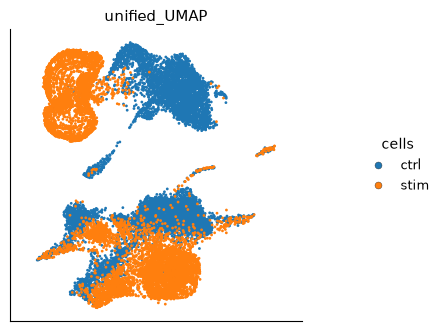

time: 104 ms (started: 2026-07-16 23:14:36 +02:00)


In [14]:
import scarf.plotting as splt

splt.unified_embedding(
    ds_ctrl,
    layout_key="unified_UMAP",
    ref_name="ctrl",
).figure

In [15]:
ds_ctrl.plot_unified_layout(
    layout_key="unified_UMAP", show_target_only=False, ref_name="ctrl"
)

time: 107 ms (started: 2026-07-16 23:14:36 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


In [16]:
ds_ctrl.project_mapping_layout(target_name="stim", reference_layout_key="RNA_UMAP")

'RNA/projections/stim/fixed_RNA_UMAP'

time: 213 ms (started: 2026-07-16 23:14:36 +02:00)


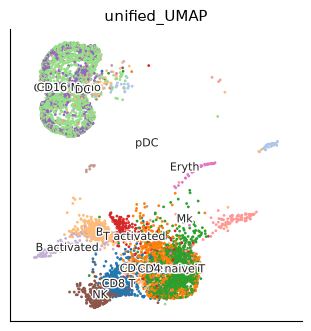

time: 153 ms (started: 2026-07-16 23:14:37 +02:00)


In [17]:
splt.unified_embedding(
    ds_ctrl,
    layout_key="unified_UMAP",
    show_target_only=True,
    target_groups=ds_stim.cells.fetch("cluster_labels"),
).figure

In [18]:
ds_ctrl.plot_unified_layout(
    layout_key="unified_UMAP",
    show_target_only=True,
    legend_ondata=True,
    target_groups=ds_stim.cells.fetch("cluster_labels"),
)

time: 89 ms (started: 2026-07-16 23:14:37 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


In [19]:
ds_ctrl.run_unified_tsne(
    target_names=["stim"],
    ini_embed_with="RNA_UMAP",
    target_weight=1,
    use_k=5,
    max_iter=500,
)

ds_ctrl.plot_unified_layout(
    layout_key="unified_tSNE", show_target_only=False, ref_name="ctrl"
)

Number of vertices: 18598


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


Maximum iterations: 500


...

Iteration 499: error is 4.28181 (50 iterations in 0.372198 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.573528 sec [21.6497%] |  Repulsive forces: 2.0756 sec [78.3503%]


time: 3.34 s (started: 2026-07-16 23:14:37 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()
